# RFJAX quickstart

This notebook shows the main permutation-based tests from the R package `RFtest`, implemented in JAX.

In [1]:
import jax.numpy as jnp
from jax import random
import rfjax

# Synthetic data: only the first two features matter
key = random.PRNGKey(0)
n, p = 300, 5
X = random.normal(key, (n, p))
beta = jnp.array([1.0, -0.5, 0.0, 0.0, 0.0])
y = X @ beta + 0.1 * random.normal(key, (n,))
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (300, 5) y shape: (300,)


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt


## Permutation F-test for one variable

In [3]:
result = rfjax.mse_test(
    X, y, var=0, n_test=50, B=500, ntree=200,
    k=80, mtry=3, max_depth=5, random_state=0,
)
print('P-value:', result['Pvalue'])
print('Importance:', result['Importance'])

P-value: {'Full Model P': 0.0019960079807788134}
Importance: {'Standard Deviation Importance': 18.53030776977539, 'Standard Normal Importance': 1.0}


## Visualize the null distribution

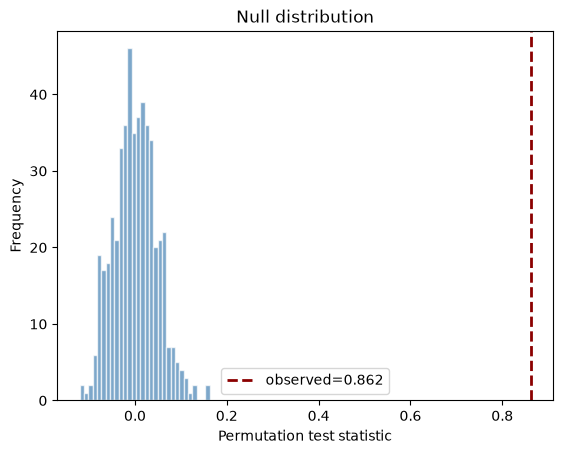

In [4]:
fig, ax = plt.subplots()
rfjax.plotting.plot_null_distribution(result, ax=ax)
plt.show()


In [5]:
result_beta_2 = rfjax.mse_test(
    X, y, var=1, n_test=50, B=500, ntree=200,
    k=80, mtry=3, max_depth=5, random_state=0,
)
print('P-value:', result_beta_2['Pvalue'])
print('Importance:', result_beta_2['Importance'])

P-value: {'Full Model P': 0.0019960079807788134}
Importance: {'Standard Deviation Importance': 13.316091537475586, 'Standard Normal Importance': 1.0}


## Visualize the null distribution

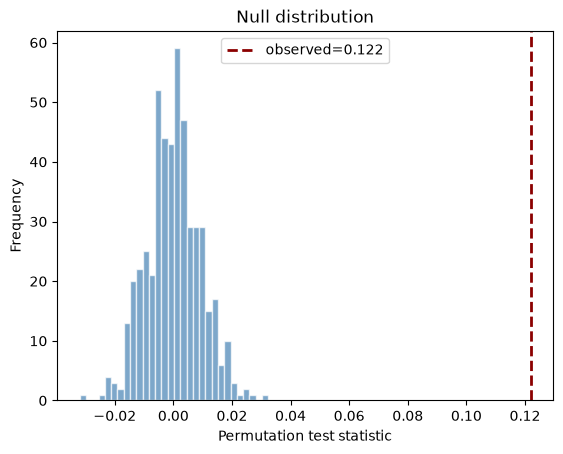

In [6]:
fig, ax = plt.subplots()
rfjax.plotting.plot_null_distribution(result_beta_2, ax=ax)
plt.show()


## Marginal permutation importance for all variables

In [7]:
imp = rfjax.permutation_importance(
    X, y, single_forest=True, n_test=50, B=500,
    nbtree=50, k=80, mtry=3, max_depth=5, random_state=0,
)
print(imp['Importance_Table'])

[[ 8.7631025e+00  6.7587376e+00 -3.1025621e-01 -2.6266938e-01
  -1.4405243e-01]
 [-7.7023035e-01 -1.3330568e-01  5.4275319e-03  4.7499910e-03
   2.1633059e-03]
 [ 1.9960080e-03  1.9960080e-03  6.3073850e-01  5.9481037e-01
   5.4491019e-01]]


## Variable importance

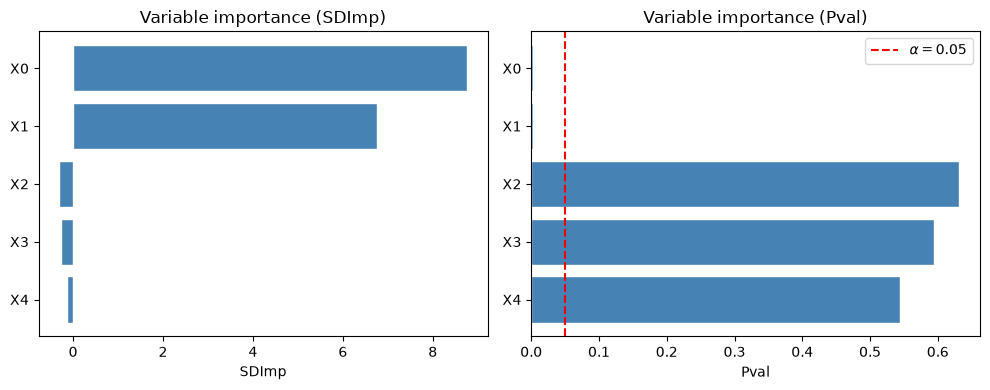

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rfjax.plotting.plot_importance(imp, kind='SDImp', ax=axes[0])
rfjax.plotting.plot_importance(imp, kind='Pval', ax=axes[1])
plt.tight_layout()
plt.show()


## Holdout-forest importance

In [9]:
himp = rfjax.holdout_rf(
    X, y, n_test=50, B=500, mintree=20, max_trees=500,
    mtry=2, k=80, max_depth=5, random_state=0,
)
print(himp['Importance_Table'])

[[ 7.5168819e+00 -1.1485382e+00 -2.0889487e+00 -7.0133895e-01
  -2.5919049e+00]
 [ 7.2141093e-01 -1.1751425e-01 -2.7377138e-01 -9.2404425e-02
  -3.5777521e-01]
 [ 1.9960080e-03  8.6826348e-01  9.8403192e-01  7.4850297e-01
   1.0000000e+00]]


## Holdout-forest importance

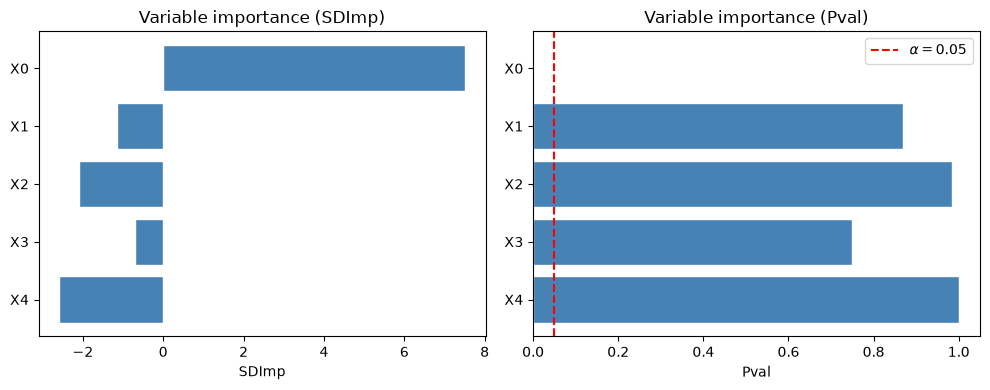

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rfjax.plotting.plot_importance(himp, kind='SDImp', ax=axes[0])
rfjax.plotting.plot_importance(himp, kind='Pval', ax=axes[1])
plt.tight_layout()
plt.show()


## Timing

In [11]:
import time

def timeit(label, fn):
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f"{label}: {elapsed:.3f}s")
    return result

timeit(
    'mse_test',
    lambda: rfjax.mse_test(X, y, var=0, n_test=50, B=500, ntree=200,
                           k=80, mtry=3, max_depth=5, random_state=0)
)
timeit(
    'permutation_importance',
    lambda: rfjax.permutation_importance(X, y, single_forest=True, n_test=50, B=500,
                                         nbtree=50, k=80, mtry=3, max_depth=5,
                                         random_state=0)
)
timeit(
    'holdout_rf',
    lambda: rfjax.holdout_rf(X, y, n_test=50, B=500, mintree=20, max_trees=500,
                             mtry=2, k=80, max_depth=5, random_state=0)
)

mse_test: 10.757s


permutation_importance: 8.167s


holdout_rf: 1.535s


{'Importance_Table': Array([[ 7.5168819e+00, -1.1485382e+00, -2.0889487e+00, -7.0133895e-01,
         -2.5919049e+00],
        [ 7.2141093e-01, -1.1751425e-01, -2.7377138e-01, -9.2404425e-02,
         -3.5777521e-01],
        [ 1.9960080e-03,  8.6826348e-01,  9.8403192e-01,  7.4850297e-01,
          1.0000000e+00]], dtype=float32),
 'call': {'mintree': 20, 'max_trees': 500, 'B': 500}}